# Task 2: Unsupervised Machine Learning

In [38]:
import logging

log_file = r"C:\Users\symev\OneDrive\Training\Emeritus\capstone project\emeritus captone project\part3_machine_learning\unsupervised_ML_models.log"

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

logger.handlers.clear()

file_handler = logging.FileHandler(
    log_file,
    mode="w",
    encoding="utf-8"
)

formatter = logging.Formatter(
    "{asctime} - {levelname} - {name} - {message}",
    style="{",
    datefmt="%Y-%m-%d %H:%M:%S"
)

file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

# Test that logging is working
logger.info("Logging started successfully.")

C:\Users\symev\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib


import seaborn as sns
import warnings
from sklearn.cluster import KMeans
sns.set(style='darkgrid')
warnings.filterwarnings('ignore')
%matplotlib inline

C:\Users\symev\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [40]:
try:
    # #load dataset that has already been cleaned, feature engineered and proxy accident risk label added
    df = pd.read_csv(r"C:\Users\symev\OneDrive\Training\Emeritus\capstone project\emeritus captone project\Metro_Interstate_Traffic_Volume_Cleaned_FeatureEngineering_wProxy.csv")

    # Get number of rows and columns
    rows, columns = df.shape

    # Log successful data loading
    logger.info(
        "Raw CSV file loaded successfully: %d rows and %d columns.",
        rows,
        columns
    )

    # Display confirmation and first few rows
    print(f"\nFile loaded successfully!")
    print(f"Rows: {rows}")
    print(f"Columns: {columns}")
    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    logger.error(f"File not found: '{file_path}'.")

except pd.errors.EmptyDataError:
    logger.error("The CSV file is empty.")

except pd.errors.ParserError:
    logger.error("The CSV file could not be parsed. Please check its format.")

except PermissionError:
    logger.error(f"Permission denied when trying to access '{file_path}'.")

except OSError as e:
    logger.error(f"Error reading the file: {e}")


File loaded successfully!
Rows: 48176
Columns: 38

First 5 rows:
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0    None  288.28      0.0      0.0          40       Clouds   
1    None  289.36      0.0      0.0          75       Clouds   
2    None  289.58      0.0      0.0          90       Clouds   
3    None  290.13      0.0      0.0          90       Clouds   
4    None  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  hour  ...  \
0    Scattered Clouds  2012-10-02 09:00:00            5545     9  ...   
1       Broken Clouds  2012-10-02 10:00:00            4516    10  ...   
2     Overcast Clouds  2012-10-02 11:00:00            4767    11  ...   
3     Overcast Clouds  2012-10-02 12:00:00            5026    12  ...   
4       Broken Clouds  2012-10-02 13:00:00            4918    13  ...   

   weather_is_clear  weather_is_not_clear  temp_scaled  traffic_volume_scaled  \
0                 0          

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48176 entries, 0 to 48175
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   holiday                     48176 non-null  object 
 1   temp                        48176 non-null  float64
 2   rain_1h                     48176 non-null  float64
 3   snow_1h                     48176 non-null  float64
 4   clouds_all                  48176 non-null  int64  
 5   weather_main                48176 non-null  object 
 6   weather_description         48176 non-null  object 
 7   date_time                   48176 non-null  object 
 8   traffic_volume              48176 non-null  int64  
 9   hour                        48176 non-null  int64  
 10  day_of_week                 48176 non-null  int64  
 11  is_weekend                  48176 non-null  int64  
 12  hour_sin                    48176 non-null  float64
 13  hour_cos                    481

In [42]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'hour',
       'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin',
       'day_of_week_cos', 'holiday_flag', 'weather_Clear', 'weather_Clouds',
       'weather_Drizzle', 'weather_Fog', 'weather_Haze', 'weather_Mist',
       'weather_Rain', 'weather_Smoke', 'weather_Snow', 'weather_Squall',
       'weather_Thunderstorm', 'weather_is_clear', 'weather_is_not_clear',
       'temp_scaled', 'traffic_volume_scaled', 'congestion_category',
       'congestion_category_High', 'congestion_category_Low',
       'congestion_category_Medium', 'congestion_category_Severe',
       'high_risk'],
      dtype='object')

In [43]:
#dataset
X = df[['rain_1h', 'snow_1h', 'clouds_all', 'hour', 'traffic_volume',
       'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos','day_of_week_sin',
       'day_of_week_cos', 'holiday_flag',
       'weather_Clear', 'weather_Clouds', 'weather_Drizzle', 'weather_Fog',
       'weather_Haze', 'weather_Mist', 'weather_Rain', 'weather_Smoke',
       'weather_Snow', 'weather_Squall', 'weather_Thunderstorm',
       'weather_is_clear', 'weather_is_not_clear', 'temp_scaled']].values

y = df['congestion_category'].values

# K means clustering 

In [44]:
logger.info("MILESTONE 1: Training Kmeans clustering model")


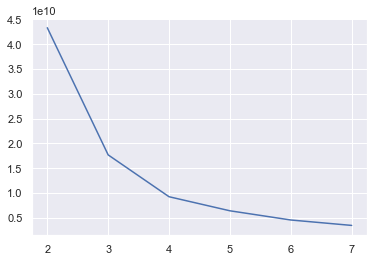

In [45]:
wcss=[]
for i in range (2,8):
    kmeans=KMeans(n_clusters=i,init='k-means++',max_iter=200,n_init=8,random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
# plot to generate elbow curve
plt.plot(range(2,8),wcss)

In [46]:
#Apply Kmeans to the dataset
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=200,n_init=8,random_state=0)
y_kmeans=kmeans.fit_predict(X)
y_kmeans.shape

(48176,)

In [47]:
df_pred_clusters=df.copy()
df_pred_clusters['Clusters'] = y_kmeans
df_pred_clusters.head(10)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,...,weather_is_not_clear,temp_scaled,traffic_volume_scaled,congestion_category,congestion_category_High,congestion_category_Low,congestion_category_Medium,congestion_category_Severe,high_risk,Clusters
0,None,288.28,0.0,0.0,40,Clouds,Scattered Clouds,2012-10-02 09:00:00,5545,9,...,1,0.673215,0.761676,Severe,0,0,0,1,0,0
1,None,289.36,0.0,0.0,75,Clouds,Broken Clouds,2012-10-02 10:00:00,4516,10,...,1,0.689412,0.620330,High,1,0,0,0,0,0
2,None,289.58,0.0,0.0,90,Clouds,Overcast Clouds,2012-10-02 11:00:00,4767,11,...,1,0.692711,0.654808,High,1,0,0,0,0,0
3,None,290.13,0.0,0.0,90,Clouds,Overcast Clouds,2012-10-02 12:00:00,5026,12,...,1,0.700960,0.690385,Severe,0,0,0,1,0,0
4,None,291.14,0.0,0.0,75,Clouds,Broken Clouds,2012-10-02 13:00:00,4918,13,...,1,0.716107,0.675549,High,1,0,0,0,0,0
5,None,291.72,0.0,0.0,1,Clear,Sky Is Clear,2012-10-02 14:00:00,5181,14,...,0,0.724805,0.711676,Severe,0,0,0,1,0,0
6,None,293.17,0.0,0.0,1,Clear,Sky Is Clear,2012-10-02 15:00:00,5584,15,...,0,0.746551,0.767033,Severe,0,0,0,1,0,0
7,None,293.86,0.0,0.0,1,Clear,Sky Is Clear,2012-10-02 16:00:00,6015,16,...,0,0.756899,0.826236,Severe,0,0,0,1,0,0
8,None,294.14,0.0,0.0,20,Clouds,Few Clouds,2012-10-02 17:00:00,5791,17,...,1,0.761098,0.795467,Severe,0,0,0,1,0,0
9,None,293.10,0.0,0.0,20,Clouds,Few Clouds,2012-10-02 18:00:00,4770,18,...,1,0.745501,0.655220,High,1,0,0,0,0,0


In [48]:
df_pred_clusters.value_counts('Clusters')

Clusters
0    20126
1    14838
2    13212
dtype: int64

<AxesSubplot:xlabel='hour', ylabel='temp'>

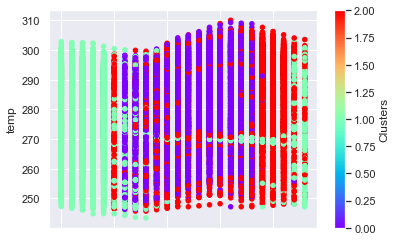

In [49]:
df_pred_clusters.plot.scatter('hour','temp',c='Clusters',cmap='rainbow')


<AxesSubplot:xlabel='hour', ylabel='traffic_volume'>

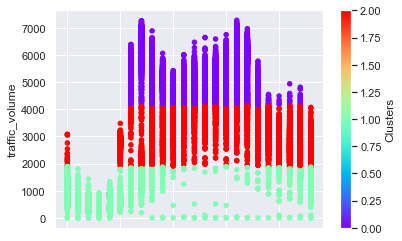

In [50]:
df_pred_clusters.plot.scatter('hour','traffic_volume',c='Clusters',cmap='rainbow')


<AxesSubplot:xlabel='rain_1h', ylabel='traffic_volume'>

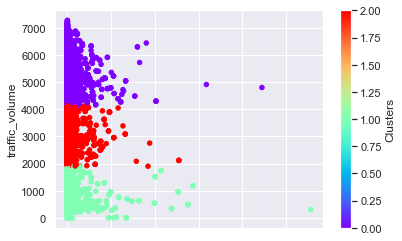

In [51]:
df_pred_clusters.plot.scatter('rain_1h','traffic_volume',c='Clusters',cmap='rainbow')


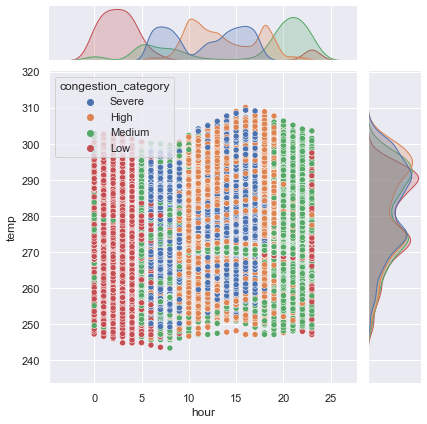

In [52]:
sns.jointplot(x = 'hour', y = 'temp', data = df, hue = 'congestion_category')

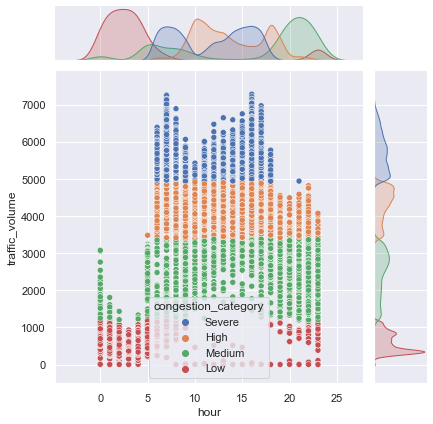

In [53]:
sns.jointplot(x = 'hour', y = 'traffic_volume', data = df, hue = 'congestion_category')

    change to 4 clusters to fit the congestion category

In [54]:
#Apply Kmeans to the dataset
kmeans4=KMeans(n_clusters=4,init='k-means++',max_iter=200,n_init=8,random_state=0)
y_kmeans4=kmeans4.fit_predict(X)
y_kmeans4.shape

(48176,)

In [55]:
df_pred_clusters=df.copy()
df_pred_clusters['Clusters'] = y_kmeans4
df_pred_clusters.head(10)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,...,weather_is_not_clear,temp_scaled,traffic_volume_scaled,congestion_category,congestion_category_High,congestion_category_Low,congestion_category_Medium,congestion_category_Severe,high_risk,Clusters
0,None,288.28,0.0,0.0,40,Clouds,Scattered Clouds,2012-10-02 09:00:00,5545,9,...,1,0.673215,0.761676,Severe,0,0,0,1,0,2
1,None,289.36,0.0,0.0,75,Clouds,Broken Clouds,2012-10-02 10:00:00,4516,10,...,1,0.689412,0.620330,High,1,0,0,0,0,3
2,None,289.58,0.0,0.0,90,Clouds,Overcast Clouds,2012-10-02 11:00:00,4767,11,...,1,0.692711,0.654808,High,1,0,0,0,0,3
3,None,290.13,0.0,0.0,90,Clouds,Overcast Clouds,2012-10-02 12:00:00,5026,12,...,1,0.700960,0.690385,Severe,0,0,0,1,0,3
4,None,291.14,0.0,0.0,75,Clouds,Broken Clouds,2012-10-02 13:00:00,4918,13,...,1,0.716107,0.675549,High,1,0,0,0,0,3
5,None,291.72,0.0,0.0,1,Clear,Sky Is Clear,2012-10-02 14:00:00,5181,14,...,0,0.724805,0.711676,Severe,0,0,0,1,0,3
6,None,293.17,0.0,0.0,1,Clear,Sky Is Clear,2012-10-02 15:00:00,5584,15,...,0,0.746551,0.767033,Severe,0,0,0,1,0,2
7,None,293.86,0.0,0.0,1,Clear,Sky Is Clear,2012-10-02 16:00:00,6015,16,...,0,0.756899,0.826236,Severe,0,0,0,1,0,2
8,None,294.14,0.0,0.0,20,Clouds,Few Clouds,2012-10-02 17:00:00,5791,17,...,1,0.761098,0.795467,Severe,0,0,0,1,0,2
9,None,293.10,0.0,0.0,20,Clouds,Few Clouds,2012-10-02 18:00:00,4770,18,...,1,0.745501,0.655220,High,1,0,0,0,0,3


In [56]:
df_pred_clusters.value_counts('Clusters')

Clusters
1    14298
3    13310
0    11421
2     9147
dtype: int64

<AxesSubplot:xlabel='hour', ylabel='temp'>

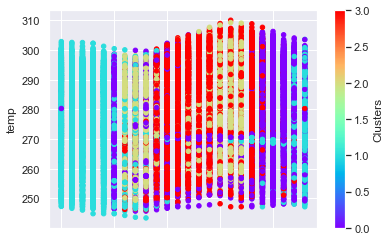

In [57]:
df_pred_clusters.plot.scatter('hour','temp',c='Clusters',cmap='rainbow')

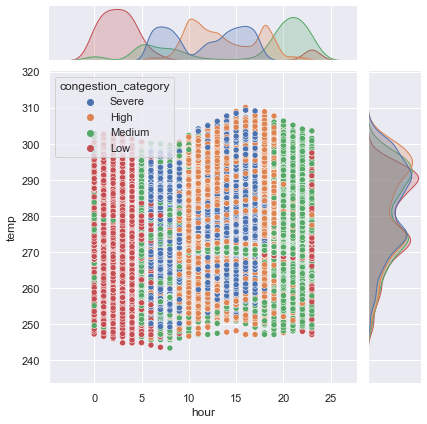

In [58]:
sns.jointplot(x = 'hour', y = 'temp', data = df, hue = 'congestion_category')

In [59]:
# Save the trained model and scaler
joblib.dump(kmeans, "classification_SVM_model.pkl")

logger.info("MILESTONE: Kmeans clustering Model saved successfully")

# Association rules mining

In [60]:
logger.info("MILESTONE 2: Association rules mining")


In [61]:
#discretize variables 
# Categorize time of day
df["date_time"] = pd.to_datetime(df["date_time"])
df["time_of_day"] = pd.cut(
    df["date_time"].dt.hour,
    bins=[-1, 5, 9, 15, 19, 23],
    labels=["Night", "Morning_Rush", "Midday",
            "Evening_Rush", "Late_Evening"]
)

# Categorize weekday type
df["weekday_type"] = (
    df["date_time"].dt.dayofweek
    .apply(lambda day: "Weekend" if day >= 5 else "Weekday")
)

# Categorize traffic volume using quantiles
df["congestion_level"] = pd.qcut(
    df["traffic_volume"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print(df[["time_of_day", "weekday_type",
          "weather_main", "congestion_category"]].head())

    time_of_day weekday_type weather_main congestion_category
0  Morning_Rush      Weekday       Clouds              Severe
1        Midday      Weekday       Clouds                High
2        Midday      Weekday       Clouds                High
3        Midday      Weekday       Clouds              Severe
4        Midday      Weekday       Clouds                High


In [62]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Select categorical variables
columns = [
    "time_of_day",
    "weekday_type",
    "weather_main",
    "congestion_level"
]

data = df[columns].dropna()

# Convert each row into a list of categorical items
transactions = []

for _, row in data.iterrows():
    transactions.append([
        f"{col}={row[col]}"
        for col in columns
    ])

# Convert transactions into one-hot encoded format
te = TransactionEncoder()
encoded = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded,
    columns=te.columns_
)

# Find frequent itemsets
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

# Keep rules that predict congestion level
rules = rules[
    rules["consequents"].apply(
        lambda items: any(
            item.startswith("congestion_level=")
            for item in items
        )
    )
].copy()

# Display the 10 rules with the highest lift
rules = rules.sort_values(
    by="lift",
    ascending=False
)

print(
    rules[
        ["antecedents", "consequents",
         "support", "confidence", "lift"]
    ].head(10).to_string(index=False)
)

                                                  antecedents                                                      consequents  support  confidence     lift
             (weekday_type=Weekday, time_of_day=Morning_Rush)                       (congestion_level=High, weather_main=Mist) 0.020695    0.169500 4.650251
                                   (time_of_day=Morning_Rush) (congestion_level=High, weather_main=Mist, weekday_type=Weekday) 0.020695    0.120702 3.484091
                    (weekday_type=Weekend, time_of_day=Night)                       (congestion_level=Low, weather_main=Clear) 0.025324    0.348571 3.339852
                                   (time_of_day=Morning_Rush)                       (congestion_level=High, weather_main=Mist) 0.020716    0.120823 3.314795
                                       (weekday_type=Weekend)                 (congestion_level=Low, time_of_day=Morning_Rush) 0.030139    0.106032 3.216744
                                          (time_of_day=Nig

In [63]:
logger.info("MILESTONE: Association mining successfully completed")